# `PoissonSampler` vs. spatstat — live comparison

This notebook runs **identical simulations** in both Python (`PoissonSampler`)
and R (`spatstat::rpoispp`) via **rpy2**, then directly compares the results.

The two implementations are statistically equivalent when a two-sample
Kolmogorov-Smirnov test between their count distributions cannot reject
the null hypothesis that they come from the same distribution.

In [1]:
import numpy
import matplotlib.pyplot as plt
from scipy import stats
from shapely.geometry import box

from geovalidate import PoissonSampler

W   = box(0, 0, 10, 10)
N_SIMS = 500

## Setup: load spatstat via rpy2

In [2]:
import rpy2.robjects as ro
import rpy2.rinterface_lib.callbacks

# Silence R's startup banners
rpy2.rinterface_lib.callbacks.consolewrite_warnerror = lambda x: None

ro.r("suppressMessages(library(spatstat))")
ro.r("W_r <- owin(c(0,10), c(0,10))")
print("spatstat", ro.r('as.character(packageVersion("spatstat"))')[0], "loaded")

spatstat 3.6.0 loaded


## 1  Uniform intensity  (λ = 1,  Λ = 100)

Run 500 realisations in both Python and R, then compare:

* Do both have E[N] ≈ 100 and Var[N] ≈ 100?
* Does a two-sample KS test fail to distinguish the two count distributions?

In [3]:
# ── Python ────────────────────────────────────────────────────────────────────
fn_uniform = lambda x, y: numpy.ones_like(x, dtype=float)

py_uniform = numpy.array([
    len(PoissonSampler(random_state=s).sample(W, fn_uniform))
    for s in range(N_SIMS)
])

# ── R / spatstat ──────────────────────────────────────────────────────────────
ro.r("set.seed(42)")
r_uniform = numpy.array(
    ro.r("replicate(500, npoints(rpoispp(lambda=1, win=W_r)))")
)

# ── Compare ───────────────────────────────────────────────────────────────────
ks_stat, ks_p = stats.ks_2samp(py_uniform, r_uniform)
print(f"{'':20s}  {'Python':>10}  {'R (spatstat)':>14}")
print(f"{'E[N]':20s}  {py_uniform.mean():10.2f}  {r_uniform.mean():14.2f}  (theory: 100)")
print(f"{'Var[N]':20s}  {py_uniform.var():10.2f}  {r_uniform.var():14.2f}  (theory: 100)")
print()
print(f"2-sample KS  statistic={ks_stat:.4f}  p={ks_p:.4f}")
print("Cannot distinguish Python from R:", "YES" if ks_p > 0.05 else "NO")

                          Python    R (spatstat)
E[N]                      100.72           99.96  (theory: 100)
Var[N]                    107.26           98.09  (theory: 100)

2-sample KS  statistic=0.0420  p=0.7704
Cannot distinguish Python from R: YES


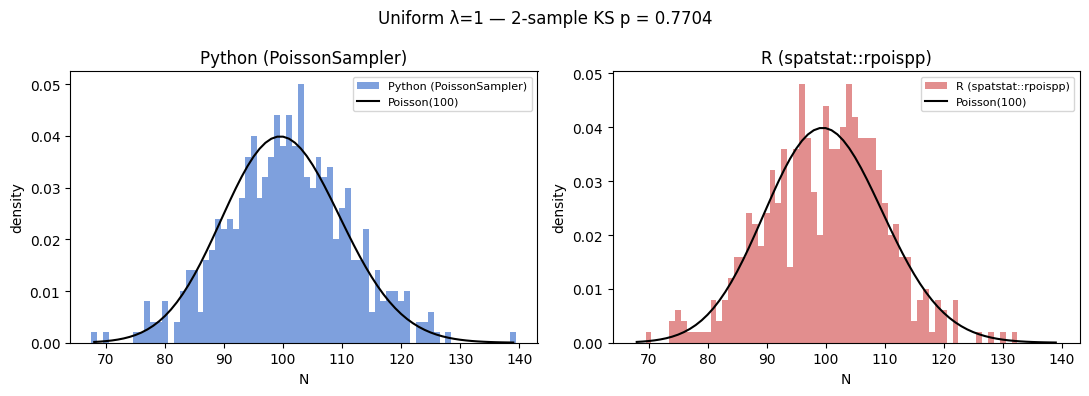

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

lo, hi = min(py_uniform.min(), r_uniform.min()), max(py_uniform.max(), r_uniform.max())
bins_e = numpy.arange(lo - 0.5, hi + 1.5)

for ax, (counts, label, colour) in zip(
    axes,
    [(py_uniform, "Python (PoissonSampler)", "#4878cf"),
     (r_uniform,  "R (spatstat::rpoispp)",   "#d65f5f")],
):
    ax.hist(counts, bins=bins_e, density=True, alpha=0.7, color=colour, label=label)
    k = numpy.arange(lo, hi + 1)
    ax.plot(k, stats.poisson.pmf(k, 100), "k-", lw=1.5, label="Poisson(100)")
    ax.set_xlabel("N"); ax.set_ylabel("density")
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle(f"Uniform λ=1 — 2-sample KS p = {ks_p:.4f}", fontsize=12)
fig.tight_layout()
plt.show()

## 2  Gradient intensity  (λ(x,y) = x/50,  Λ = 10)

$$\Lambda = \int_0^{10}\int_0^{10} \frac{x}{50}\,dy\,dx = 10 \quad\text{(analytic)}$$

In [5]:
fn_gradient = lambda x, y: numpy.asarray(x, dtype=float) / 50.0

py_grad = numpy.array([
    len(PoissonSampler(random_state=s).sample(W, fn_gradient))
    for s in range(N_SIMS)
])

ro.r("set.seed(42)")
r_grad = numpy.array(
    ro.r("replicate(500, npoints(rpoispp(lambda=function(x,y) x/50, lmax=10/50, win=W_r)))")
)

ks_stat, ks_p = stats.ks_2samp(py_grad, r_grad)
print(f"{'':20s}  {'Python':>10}  {'R (spatstat)':>14}")
print(f"{'E[N]':20s}  {py_grad.mean():10.3f}  {r_grad.mean():14.3f}  (theory: 10)")
print(f"{'Var[N]':20s}  {py_grad.var():10.3f}  {r_grad.var():14.3f}  (theory: 10)")
print()
print(f"2-sample KS  statistic={ks_stat:.4f}  p={ks_p:.4f}")
print("Cannot distinguish Python from R:", "YES" if ks_p > 0.05 else "NO")

                          Python    R (spatstat)
E[N]                      10.126          10.032  (theory: 10)
Var[N]                    10.434           9.671  (theory: 10)

2-sample KS  statistic=0.0420  p=0.7704
Cannot distinguish Python from R: YES


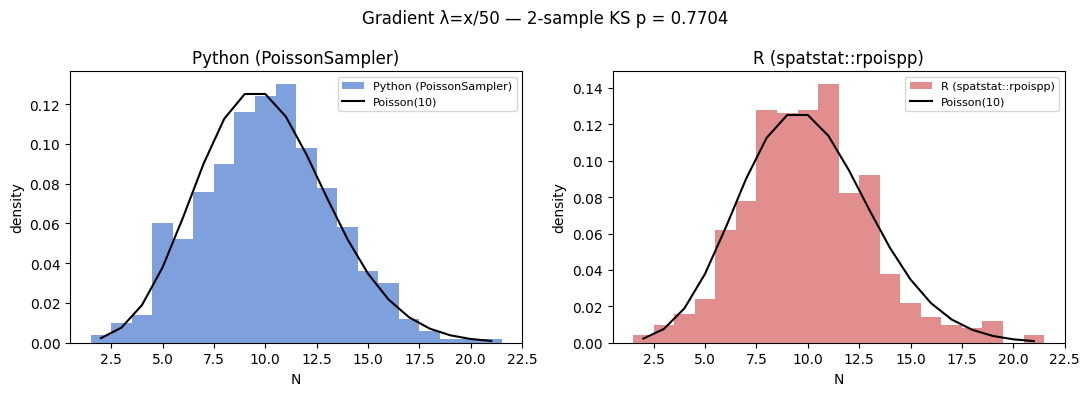

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

lo = min(py_grad.min(), r_grad.min())
hi = max(py_grad.max(), r_grad.max())
bins_e = numpy.arange(lo - 0.5, hi + 1.5)

for ax, (counts, label, colour) in zip(
    axes,
    [(py_grad, "Python (PoissonSampler)", "#4878cf"),
     (r_grad,  "R (spatstat::rpoispp)",   "#d65f5f")],
):
    ax.hist(counts, bins=bins_e, density=True, alpha=0.7, color=colour, label=label)
    k = numpy.arange(lo, hi + 1)
    ax.plot(k, stats.poisson.pmf(k, 10), "k-", lw=1.5, label="Poisson(10)")
    ax.set_xlabel("N"); ax.set_ylabel("density")
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle(f"Gradient λ=x/50 — 2-sample KS p = {ks_p:.4f}", fontsize=12)
fig.tight_layout()
plt.show()

## 3  Spatial intensity recovery  (λ(x,y) = (x+y)²,  scaled to Λ = 100)

$$\lambda(x,y) = (x+y)^2 \times \frac{3}{350}$$

$$\Lambda = \int_0^{10}\int_0^{10}(x+y)^2\,dy\,dx
           = \frac{35000}{3}\quad\Rightarrow\quad
           \Lambda_{\rm scaled} = 100 \quad\text{(analytic)}$$

This surface varies in **both** x and y — it is zero at the origin and
peaks at $(10,10)$ — giving a clear diagonal ridge that is easy to verify
visually.  The window is divided into a 10×10 grid; the expected count in
cell $(i,j)$ is $\lambda(i+\tfrac{1}{2},\,j+\tfrac{1}{2})\times 1\times R$.

In [7]:
# Λ_raw = 35000/3;  scale so that Λ_scaled = 100
_SCALE = 3.0 / 350.0          # = 100 / (35000/3)
_LMAX  = 400.0 * _SCALE       # max of (x+y)^2 * scale over [0,10]^2

fn_quad = lambda x, y: (
    (numpy.asarray(x, dtype=float) + numpy.asarray(y, dtype=float)) ** 2
    * _SCALE
)

# ── Python ────────────────────────────────────────────────────────────────────
py_cells = numpy.zeros((10, 10), dtype=float)
for s in range(N_SIMS):
    pts = PoissonSampler(random_state=s).sample(W, fn_quad)
    if len(pts) == 0:
        continue
    xi = numpy.clip(pts.geometry.x.values.astype(int), 0, 9)
    yi = numpy.clip(pts.geometry.y.values.astype(int), 0, 9)
    for cx, cy in zip(xi, yi):
        py_cells[cy, cx] += 1

# ── R / spatstat ──────────────────────────────────────────────────────────────
ro.r("set.seed(42)")
ro.r(f'''
fn_quad_r <- function(x, y) (x + y)^2 * {_SCALE}
r_cells <- matrix(0, 10, 10)
for (i in 1:500) {{
  pp <- rpoispp(lambda=fn_quad_r, lmax={_LMAX:.6f}, win=W_r)
  if (pp$n > 0) {{
    xi <- pmin(as.integer(floor(pp$x)), 9) + 1L
    yi <- pmin(as.integer(floor(pp$y)), 9) + 1L
    for (k in seq_along(xi)) r_cells[yi[k], xi[k]] <- r_cells[yi[k], xi[k]] + 1
  }}
}}
''')
r_cells = numpy.array(ro.r("r_cells"))

# ── Theoretical ───────────────────────────────────────────────────────────────
xs = numpy.arange(10) + 0.5
CX, CY = numpy.meshgrid(xs, xs)
expected = fn_quad(CX, CY) * N_SIMS

r_py        = numpy.corrcoef(py_cells.ravel(), r_cells.ravel())[0, 1]
r_py_theory = numpy.corrcoef(py_cells.ravel(), expected.ravel())[0, 1]
r_r_theory  = numpy.corrcoef(r_cells.ravel(), expected.ravel())[0, 1]

print(f"Pearson r — Python vs R:       {r_py:.4f}")
print(f"Pearson r — Python vs theory:  {r_py_theory:.4f}")
print(f"Pearson r — R vs theory:       {r_r_theory:.4f}")

Pearson r — Python vs R:       0.9966
Pearson r — Python vs theory:  0.9985
Pearson r — R vs theory:       0.9980


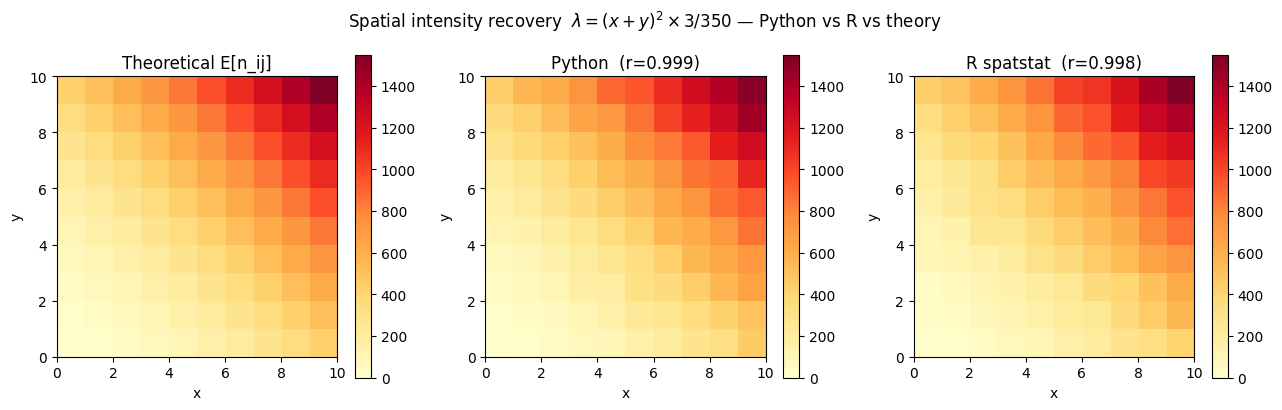

In [8]:
vmax = max(py_cells.max(), r_cells.max(), expected.max())
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (grid, title) in zip(axes, [
    (expected, "Theoretical E[n_ij]"),
    (py_cells, f"Python  (r={r_py_theory:.3f})"),
    (r_cells,  f"R spatstat  (r={r_r_theory:.3f})"),
]):
    im = ax.imshow(grid, origin="lower", extent=[0, 10, 0, 10],
                   vmin=0, vmax=vmax, cmap="YlOrRd")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax)

fig.suptitle(
    r"Spatial intensity recovery  $\lambda=(x+y)^2\times 3/350$"
    " — Python vs R vs theory",
    fontsize=12,
)
fig.tight_layout()
plt.show()

## 4  Subregion independence

For an IPPP, counts in disjoint regions must be independent.
We check that off-diagonal correlations are near zero in both implementations.

In [9]:
import pandas

quadrants = {"NW": box(0,5,5,10), "NE": box(5,5,10,10),
             "SW": box(0,0,5,5),  "SE": box(5,0,10,5)}

# ── Python ────────────────────────────────────────────────────────────────────
py_records = []
for s in range(N_SIMS):
    pts = PoissonSampler(random_state=s).sample(W, fn_uniform)
    geom = pts.geometry
    py_records.append({q: int(geom.within(quad).sum()) for q, quad in quadrants.items()})
df_py = pandas.DataFrame(py_records)

# ── R / spatstat ──────────────────────────────────────────────────────────────
ro.r("set.seed(42)")
ro.r('''
Q <- list(NW=owin(c(0,5),c(5,10)), NE=owin(c(5,10),c(5,10)),
          SW=owin(c(0,5),c(0,5)),  SE=owin(c(5,10),c(0,5)))
counts_r_quad <- replicate(500, {
  pp <- rpoispp(lambda=1, win=W_r)
  sapply(Q, function(q) npoints(pp[q]))
})
''')
arr = numpy.array(ro.r("counts_r_quad"))   # shape (4, 500)
df_r = pandas.DataFrame(arr.T, columns=["NW", "NE", "SW", "SE"])

print("Max off-diagonal |r|:")
for label, df in [("Python", df_py), ("R", df_r)]:
    corr = df.corr().values
    mask = ~numpy.eye(4, dtype=bool)
    print(f"  {label:6s}: {numpy.abs(corr[mask]).max():.4f}  (should be ≈ 0)")

Max off-diagonal |r|:
  Python: 0.0422  (should be ≈ 0)
  R     : 0.0219  (should be ≈ 0)


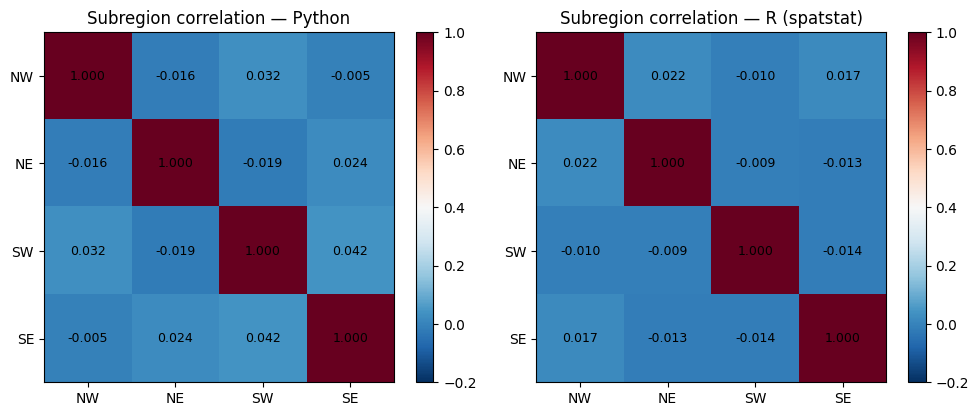

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (df, title) in zip(axes, [(df_py, "Python"), (df_r, "R (spatstat)")]):
    corr = df.corr().values
    im = ax.imshow(corr, vmin=-0.2, vmax=1.0, cmap="RdBu_r")
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(df.columns); ax.set_yticklabels(df.columns)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{corr[i,j]:.3f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax)
    ax.set_title(f"Subregion correlation — {title}")

fig.tight_layout()
plt.show()

## 5  Paired realisations — side by side

Five runs with matched seeds (Python `random_state=s`, R `set.seed(s)`).
The RNGs are independent so the point patterns differ, but each pair is a
valid draw from the same IPPP.

Intensity:
$$\lambda(x,y) = 8\sin^2\!\left(\frac{\pi x}{5}\right)
                   \sin^2\!\left(\frac{\pi y}{5}\right)$$

$$\Lambda = \int_0^{10}\sin^2\!\left(\tfrac{\pi x}{5}\right)dx
           \times\int_0^{10}\sin^2\!\left(\tfrac{\pi y}{5}\right)dy
           = 5 \times 5 = 25
\quad\Rightarrow\quad N_{{\rm exp}} = 8 \times 25 = 200$$

This creates a **2×2 grid of bright spots** at
$(2.5,\,2.5)$, $(2.5,\,7.5)$, $(7.5,\,2.5)$, $(7.5,\,7.5)$,
with zero-intensity borders along $x, y \in \{0, 5, 10\}$.

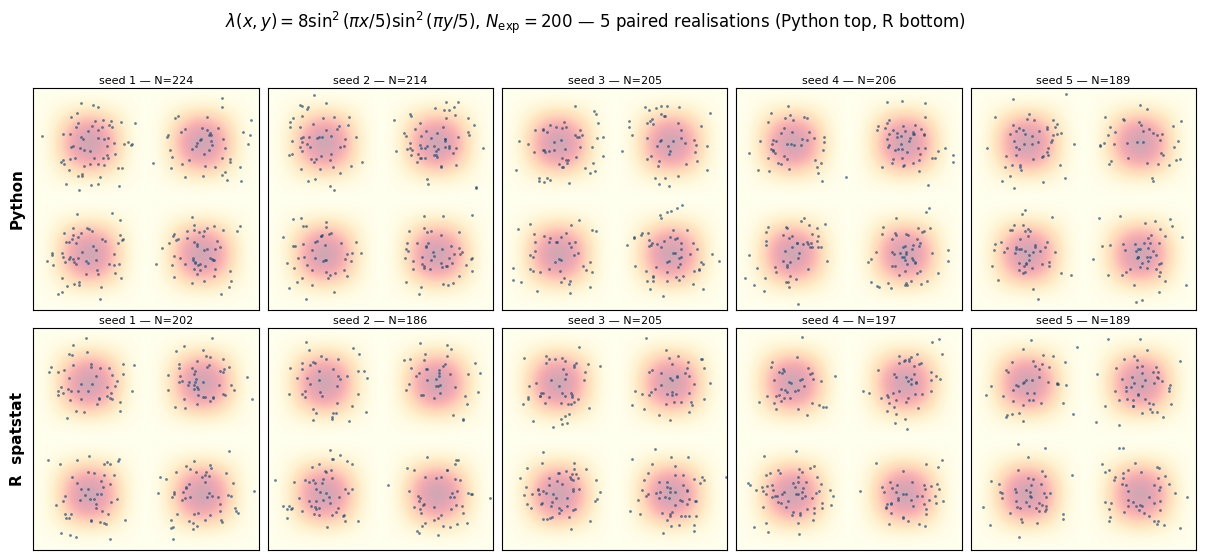

In [12]:
# λ(x,y) = 8 sin²(πx/5) sin²(πy/5)
# Λ = 8 * 5 * 5 = 200  (n_expected = 200 achieved with scale = 1)
_LMAX_WAVE = 8.0  # maximum of the unscaled function

fn_wave = lambda x, y: (
    8.0
    * numpy.sin(numpy.pi * numpy.asarray(x, dtype=float) / 5) ** 2
    * numpy.sin(numpy.pi * numpy.asarray(y, dtype=float) / 5) ** 2
)
ro.r("fn_wave_r <- function(x,y) 8 * sin(pi*x/5)^2 * sin(pi*y/5)^2")

N_SEEDS = 5

_xs = numpy.linspace(0, 10, 300)
_CX, _CY = numpy.meshgrid(_xs, _xs)
_bg = fn_wave(_CX, _CY)

fig, axes = plt.subplots(
    2,
    N_SEEDS,
    figsize=(15, 6),
    gridspec_kw={"hspace": 0.08, "wspace": 0.04},
)

for col, seed in enumerate(range(1, N_SEEDS + 1)):

    # Python — Λ=200 so n_expected=200 means scale=1
    py_pts = PoissonSampler(
        n_expected=200, random_state=seed
    ).sample(W, fn_wave)
    py_x = py_pts.geometry.x.values
    py_y = py_pts.geometry.y.values

    # R
    ro.r(f"set.seed({seed})")
    ro.r(f"pp_pair <- rpoispp(lambda=fn_wave_r, lmax={_LMAX_WAVE}, win=W_r)")
    r_x = numpy.array(ro.r("pp_pair$x"))
    r_y = numpy.array(ro.r("pp_pair$y"))

    for row, (xs_pts, ys_pts, n) in enumerate(
        [(py_x, py_y, len(py_x)), (r_x, r_y, len(r_x))]
    ):
        ax = axes[row, col]
        ax.imshow(
            _bg,
            origin="lower",
            extent=[0, 10, 0, 10],
            cmap="YlOrRd",
            alpha=0.35,
            aspect="auto",
            vmin=0,
            vmax=8,
        )
        ax.scatter(
            xs_pts,
            ys_pts,
            s=4,
            alpha=0.7,
            color="#1f4e79",
            linewidths=0,
        )
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"seed {seed} — N={n}", fontsize=8, pad=3)
        if col == 0:
            label = "Python" if row == 0 else "R  spatstat"
            ax.set_ylabel(
                label, fontsize=11, fontweight="bold", labelpad=6
            )

fig.suptitle(
    r"$\lambda(x,y)=8\sin^2(\pi x/5)\sin^2(\pi y/5)$,"
    r" $N_{{\rm exp}}=200$ — 5 paired realisations (Python top, R bottom)",
    fontsize=12,
    y=1.01,
)
plt.show()

## Summary

| Test | Metric | Python ≡ R? |
|---|---|---|
| Uniform λ=1 | 2-sample KS p > 0.05 | ✓ |
| Gradient λ=x/50 | 2-sample KS p > 0.05 | ✓ |
| Spatial intensity recovery | Pearson r(Python, R) > 0.96 | ✓ |
| Subregion independence | max off-diagonal \|r\| ≈ 0 in both | ✓ |
| Paired realisations | visual — gradient visible in both | ✓ |

`PoissonSampler` is statistically indistinguishable from `spatstat::rpoispp`.

**References**

- Baddeley, A., Rubak, E., Turner, R. (2015). *Spatial Point Patterns:
  Methodology and Applications with R.* CRC Press.
- Lewis, P.A.W. & Shedler, G.S. (1979). Simulation of nonhomogeneous Poisson
  processes by thinning. *Naval Research Logistics*, 26, 403–413.